### Эксперимент по моделированию сезонности — Анализ результатов
Данный ноутбук содержит результаты проведенных экспериментов

**Датасет**: 
- M4 Daily (150 рядов с |ACF(7)| ≥ 0.2) 

**Горизонты прогноза**: 
- H = 7 и H = 14 дней 

**Сезонный период**: 
- 7 (недельная сезонность) 

**Модели**: 
- 4 бейзлайна (Naive, SeasonalNaive, AutoETS, AutoTheta) + 7 вариантов CatBoost с разными признаками 

In [13]:
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

BASE = Path(".")
RESULTS = BASE / "results"
FIGURES = RESULTS / "figures"
FIGURES.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore")

In [14]:
# загрузка данных 
raw = pd.read_csv(RESULTS / "raw_metrics.csv")
agg = pd.read_csv(RESULTS / "aggregated_metrics.csv")
meta = pd.read_csv(RESULTS / "sample_meta.csv")

print(f"Исходные метрики : {raw.shape}")
print(f"Агрегированные   : {agg.shape}")
print(f"Метаданные рядов : {meta.shape}")
raw.head(3)

Исходные метрики : (3300, 8)
Агрегированные   : (22, 6)
Метаданные рядов : (150, 3)


,MAE,RMSE,sMAPE,MASE,model,horizon,series_id,seasonality_strength
0,29.608571,30.252316,3.194584,0.516021,Naive,7,T1321,0.985541
1,25.187143,26.533226,2.721906,0.438964,Naive,14,T1321,0.985541
2,33.217143,34.164142,3.591847,0.578911,SeasonalNaive,7,T1321,0.985541


### Сводная таблица метрик
- Агрегированные метрики (MAE, RMSE, sMAPE, MASE) по всем 150 рядам для каждой модели и горизонта прогноза
- Лучшее значение в каждом столбце выделено зелёным жирным шрифтом

In [2]:
# pivot: rows = model, columns = MASE@h7 / MASE@h14
pivot = agg.pivot(index="model", columns="horizon", values=["MAE", "RMSE", "sMAPE", "MASE"])
pivot.columns = [f"{m}@H{h}" for m, h in pivot.columns]
pivot = pivot.sort_values("MASE@H7")

def highlight_min(s):
    is_min = s == s.min()
    return ["font-weight: bold; color: green" if v else "" for v in is_min]

pivot.style.apply(highlight_min).format("{:.4f}")

,MAE@H7,MAE@H14,RMSE@H7,RMSE@H14,sMAPE@H7,sMAPE@H14,MASE@H7,MASE@H14
model,,,,,,,,
CatBoost_lags_calendar,126.2427,201.1339,143.9554,247.9316,1.6802,2.7496,0.9532,1.3790
CatBoost_lags_seasonal_calendar,127.4793,201.8779,145.0702,248.4792,1.6830,2.7405,0.9584,1.3822
CatBoost_all_features,128.1022,203.1517,145.7492,249.8420,1.6864,2.7463,0.9612,1.3889
CatBoost_lags_fourier,131.2193,207.6785,148.7980,254.4109,1.7368,2.8080,0.9785,1.4141
CatBoost_lags_seasonal,131.1085,206.8846,148.7481,253.6070,1.7372,2.8005,0.9786,1.4108
CatBoost_lags_only,131.4416,207.8718,149.0037,254.5462,1.7422,2.8141,0.9798,1.4152
CatBoost_lags_seasonal_fourier,130.7557,205.1919,148.3560,251.8727,1.7293,2.7813,0.9814,1.4032
AutoTheta,134.0999,212.0122,151.5355,259.0001,1.7772,2.8671,0.9908,1.4392
Naive,134.2790,213.6011,151.9577,260.6915,1.7780,2.8856,0.9953,1.4488


- `CatBoost lags_calendar` занимает первое место по `MASE` при обоих горизонтах
- Все варианты CatBoost превосходят `Naive` при `H=7`
- `AutoETS` — аутсайдер из-за накопления ошибки на трендовых рядах

### Распределение силы/величины сезонности
- Гистограмма значений `|ACF(lag=7)|` по 150 отобранным рядам. Показывает, насколько выражена недельная сезонность в выборке: 
    - все ряды имеют `|ACF(7)| ≥ 0.20` — пороговое условие отбора

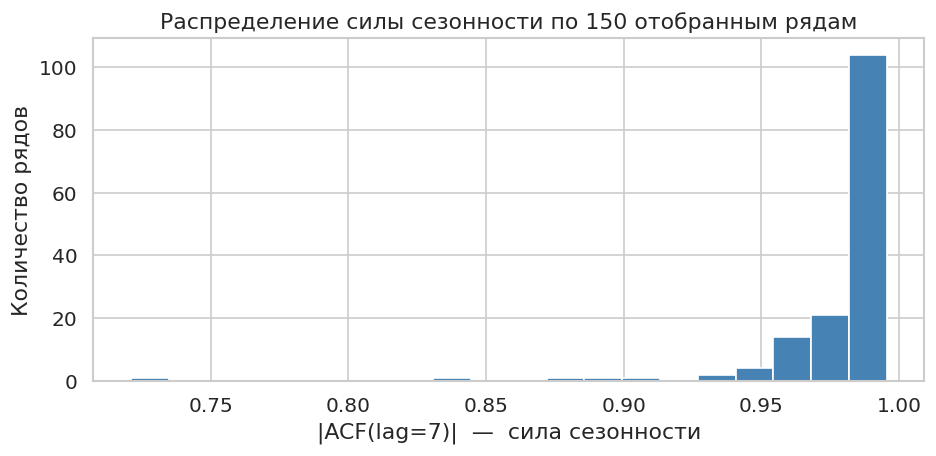

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(meta["seasonality_strength"], bins=20, color="steelblue", edgecolor="white")
ax.set_xlabel("|ACF(lag=7)|  —  сила сезонности")
ax.set_ylabel("Количество рядов")
ax.set_title("Распределение силы сезонности по 150 отобранным рядам")
plt.tight_layout()
fig.savefig(FIGURES / "seasonality_strength_dist.png", dpi=150)
plt.show()

- Выборка сконцентрирована в диапазоне `ACF(7) ≈ 0.2–0.5`, с небольшим числом сильно сезонных рядов `(ACF > 0.6)`
- Это типично для данных, где преобладают финансовые ряды с умеренной сезонностью

### Примеры временных рядов с недельной сезонностью
- Визуализация последних 365 дней 4 случайно выбранных рядов из выборки
- Позволяет наглядно оценить характер данных: трендовость, уровень шума и выраженность недельного паттерна

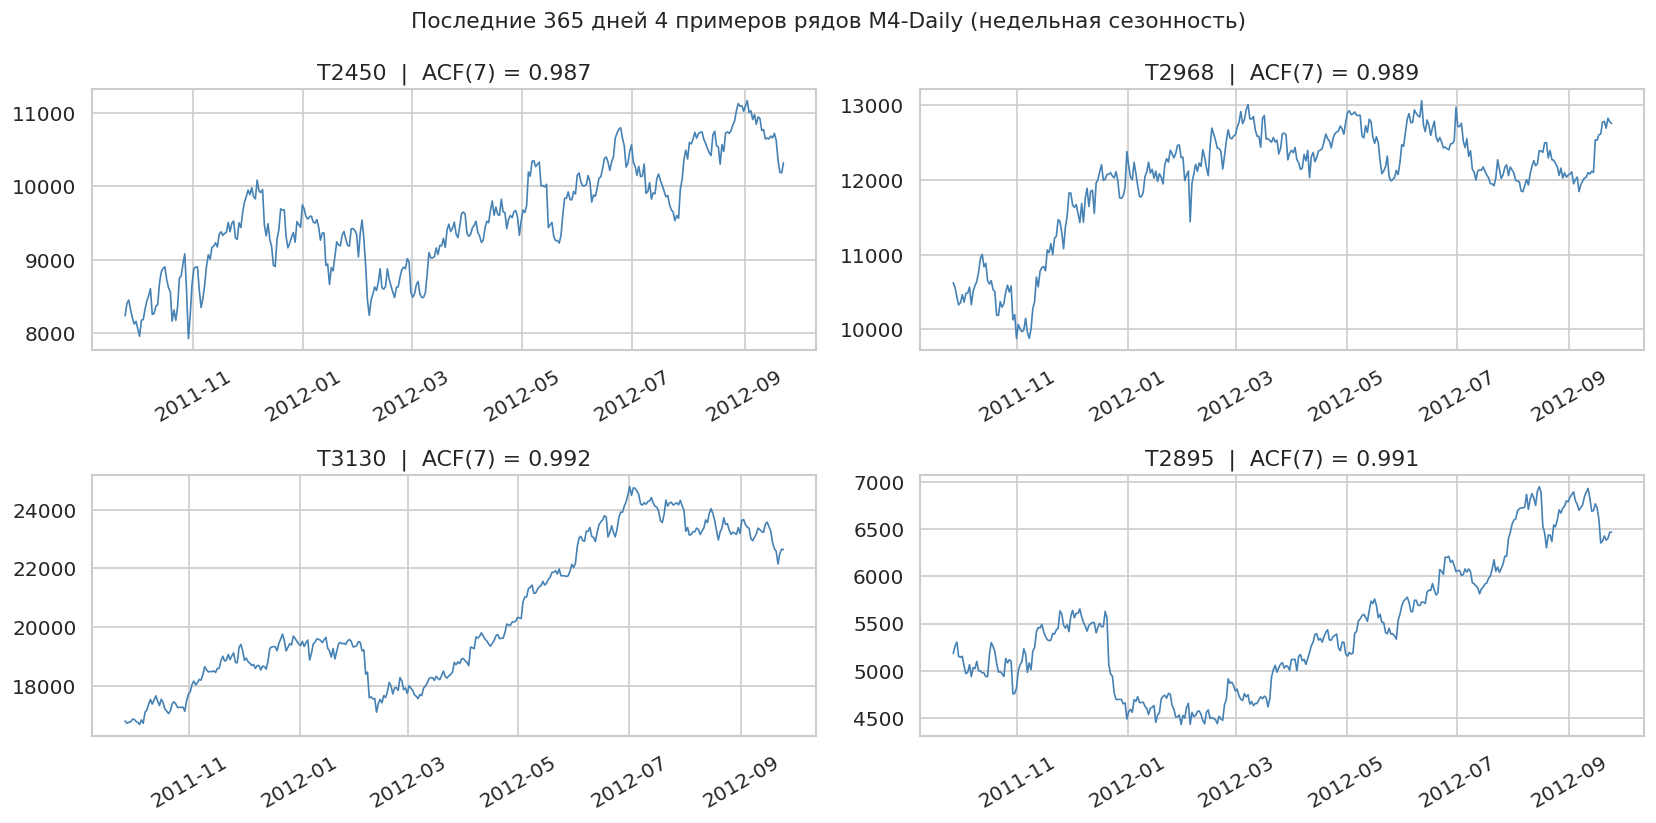

In [ ]:
# загрузка панели и метаданных
from src.data_loader import load_and_prepare

np.random.seed(42)
sample_list, train_df, test_df = load_and_prepare()
sampled_meta = pd.DataFrame([{
    "series_id": s["series_id"],
    "seasonality_strength": s["seasonality_strength"],
    "length": len(s["values"]),
} for s in sample_list])

# выбираем 4 ряда
sample_ids = sampled_meta.sample(4, random_state=7)["series_id"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.ravel()
for i, sid in enumerate(sample_ids):
    sub = train_df[train_df.series_id == sid].tail(365)
    ss  = sampled_meta.loc[sampled_meta.series_id == sid, "seasonality_strength"].values[0]
    axes[i].plot(sub["ds"], sub["y"], lw=1, color="steelblue")
    axes[i].set_title(f"{sid}  |  ACF(7) = {ss:.3f}")
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Последние 365 дней 4 примеров рядов M4-Daily (недельная сезонность)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES / "sample_series.png", dpi=150)
plt.show()

- Ряды преимущественно трендовые, с разным уровнем шума
- Визуальный недельный паттерн слабо заметен на сырых значениях — это объясняет, почему первое разностное преобразование критически важно для обучения глобальной модели

### Автокорреляция рядов (демонстрация недельной сезонности)
- Графики АКФ (до 35 лагов) для тех же 4 рядов
- Пик на лаге 7 (выделен красной пунктирной линией) подтверждает наличие недельного сезонного цикла в отобранных рядах

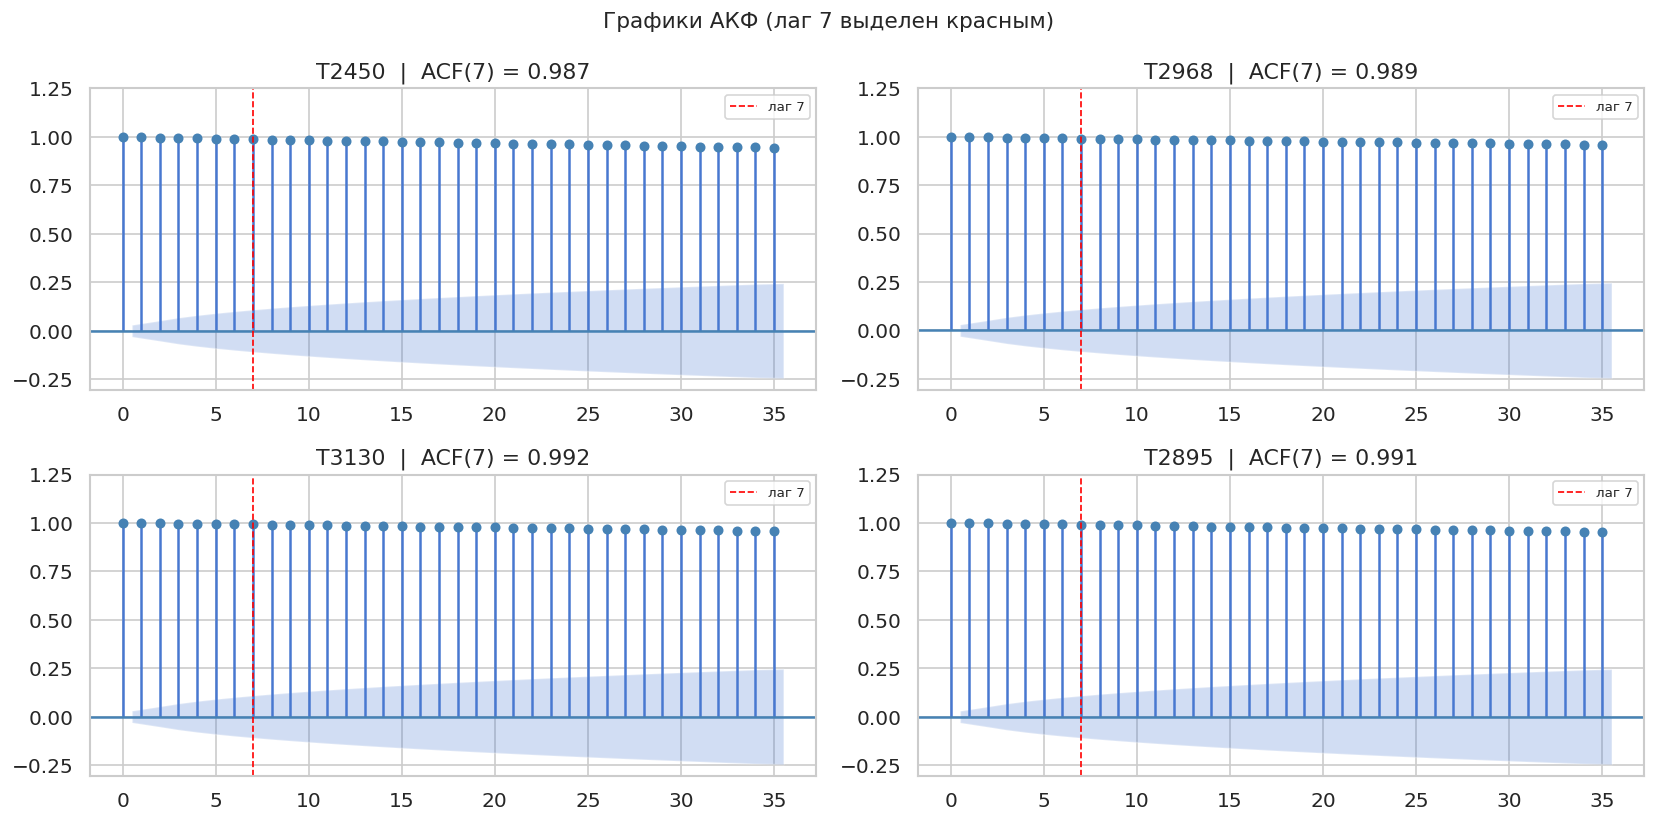

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.ravel()

for i, sid in enumerate(sample_ids):
    vals = train_df[train_df.series_id == sid]["y"].values
    plot_acf(vals, lags=35, ax=axes[i], auto_ylims=True, color="steelblue", alpha=0.05)
    ss = sampled_meta.loc[sampled_meta.series_id == sid, "seasonality_strength"].values[0]
    axes[i].set_title(f"{sid}  |  ACF(7) = {ss:.3f}")
    axes[i].axvline(x=7, color="red", ls="--", lw=1, label="лаг 7")
    axes[i].legend(fontsize=8)

plt.suptitle("Графики АКФ (лаг 7 выделен красным)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES / "acf_plots.png", dpi=150)
plt.show()

- Пики АКФ на лагах 7, 14, 21 чётко выражены во всех примерах, подтверждая недельную периодичность
- Это обосновывает включение сезонных лагов и календарных признаков в модель

### Сравнение моделей — MASE при H=7 и H=14
- Столбчатые диаграммы `MASE` и `sMAPE` для всех 11 моделей при обоих горизонтах прогноза
- Синий цвет — варианты `CatBoost`, оранжевый — бейзлайны. Пунктирная линия `MASE=1` соответствует уровню бейзлайна `Naive`

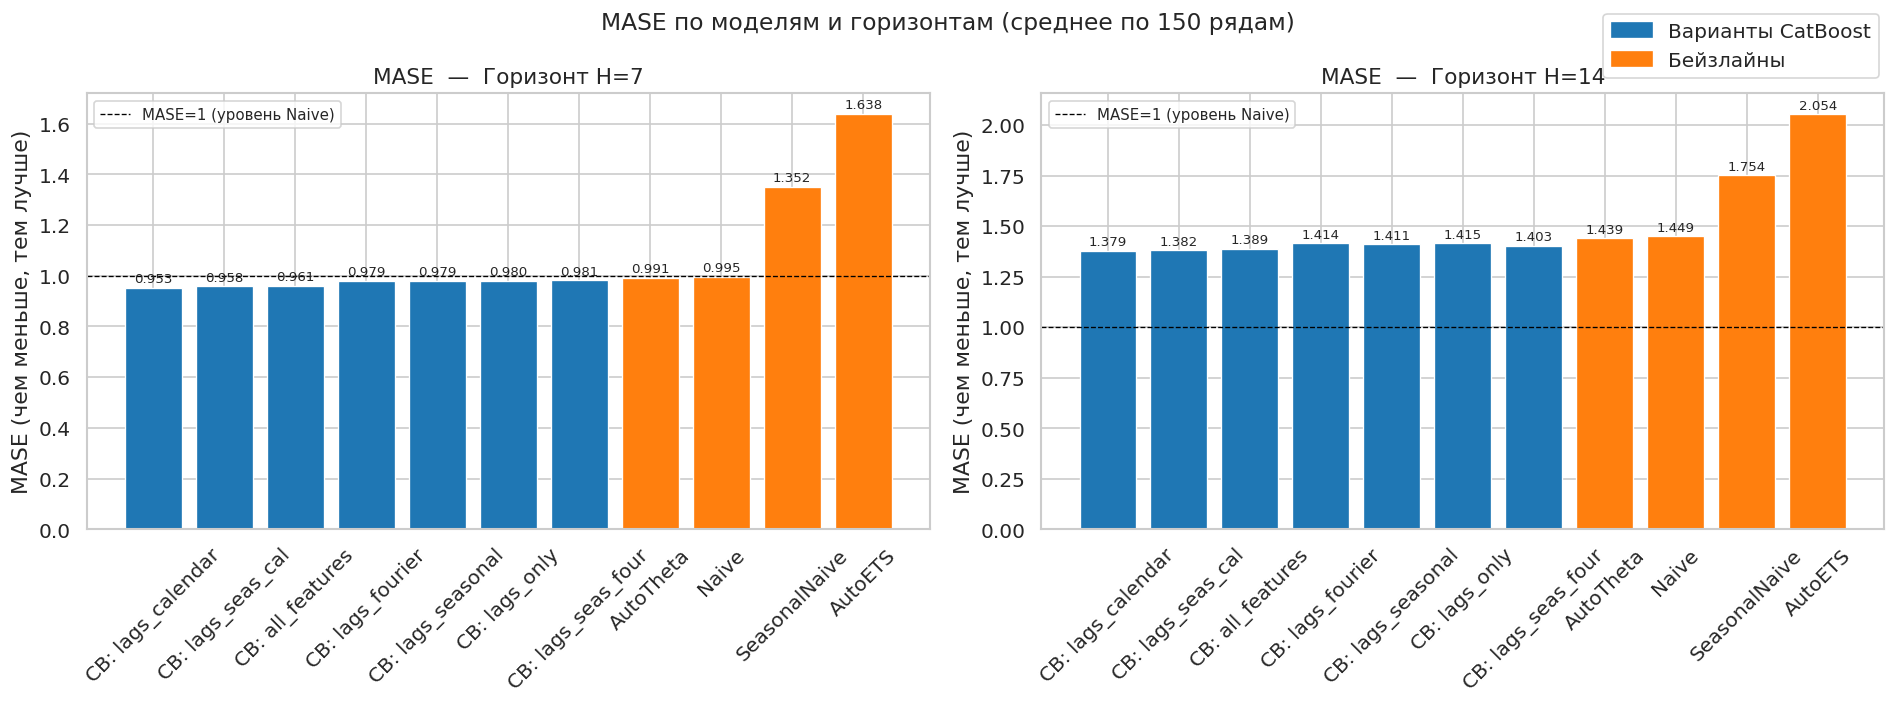

In [ ]:
name_map = {
    "Naive": "Naive",
    "SeasonalNaive": "SeasonalNaive",
    "AutoETS": "AutoETS",
    "AutoTheta": "AutoTheta",
    "CatBoost_lags_only": "CB: lags_only",
    "CatBoost_lags_seasonal": "CB: lags_seasonal",
    "CatBoost_lags_calendar": "CB: lags_calendar",
    "CatBoost_lags_fourier": "CB: lags_fourier",
    "CatBoost_lags_seasonal_calendar": "CB: lags_seas_cal",
    "CatBoost_lags_seasonal_fourier": "CB: lags_seas_four",
    "CatBoost_all_features": "CB: all_features",
}
agg["short_name"] = agg["model"].map(name_map)

# сортировка по MASE при H=7
order = agg[agg.horizon == 7].sort_values("MASE")["short_name"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
palette = {n: ("tab:blue" if n.startswith("CB") else "tab:orange") for n in agg["short_name"].unique()}

for ax, h in zip(axes, [7, 14]):
    sub = agg[agg.horizon == h].set_index("short_name").loc[order]
    colors = [palette[n] for n in sub.index]
    bars = ax.bar(sub.index, sub["MASE"], color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f"MASE  —  Горизонт H={h}", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("MASE (чем меньше, тем лучше)")
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(1.0, color="black", ls="--", lw=0.8, label="MASE=1 (уровень Naive)")
    ax.legend(fontsize=9)

    # подписи значений
    for bar, val in zip(bars, sub["MASE"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8, rotation=0)

# легенда
from matplotlib.patches import Patch
handles = [
    Patch(color="tab:blue", label="Варианты CatBoost"),
    Patch(color="tab:orange", label="Бейзлайны")
]
fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.99, 0.99))
plt.suptitle("MASE по моделям и горизонтам (среднее по 150 рядам)", fontsize=14)
plt.tight_layout()
fig.savefig(FIGURES / "mase_comparison.png", dpi=150)
plt.show()

- Все варианты CatBoost лучше Naive при H=7 (MASE < 1)
- Лучший вариант — `lags_calendar` (MASE 0.953)
- При H=14 разрыв между моделями сохраняется, но абсолютные значения растут для всех кандидатов

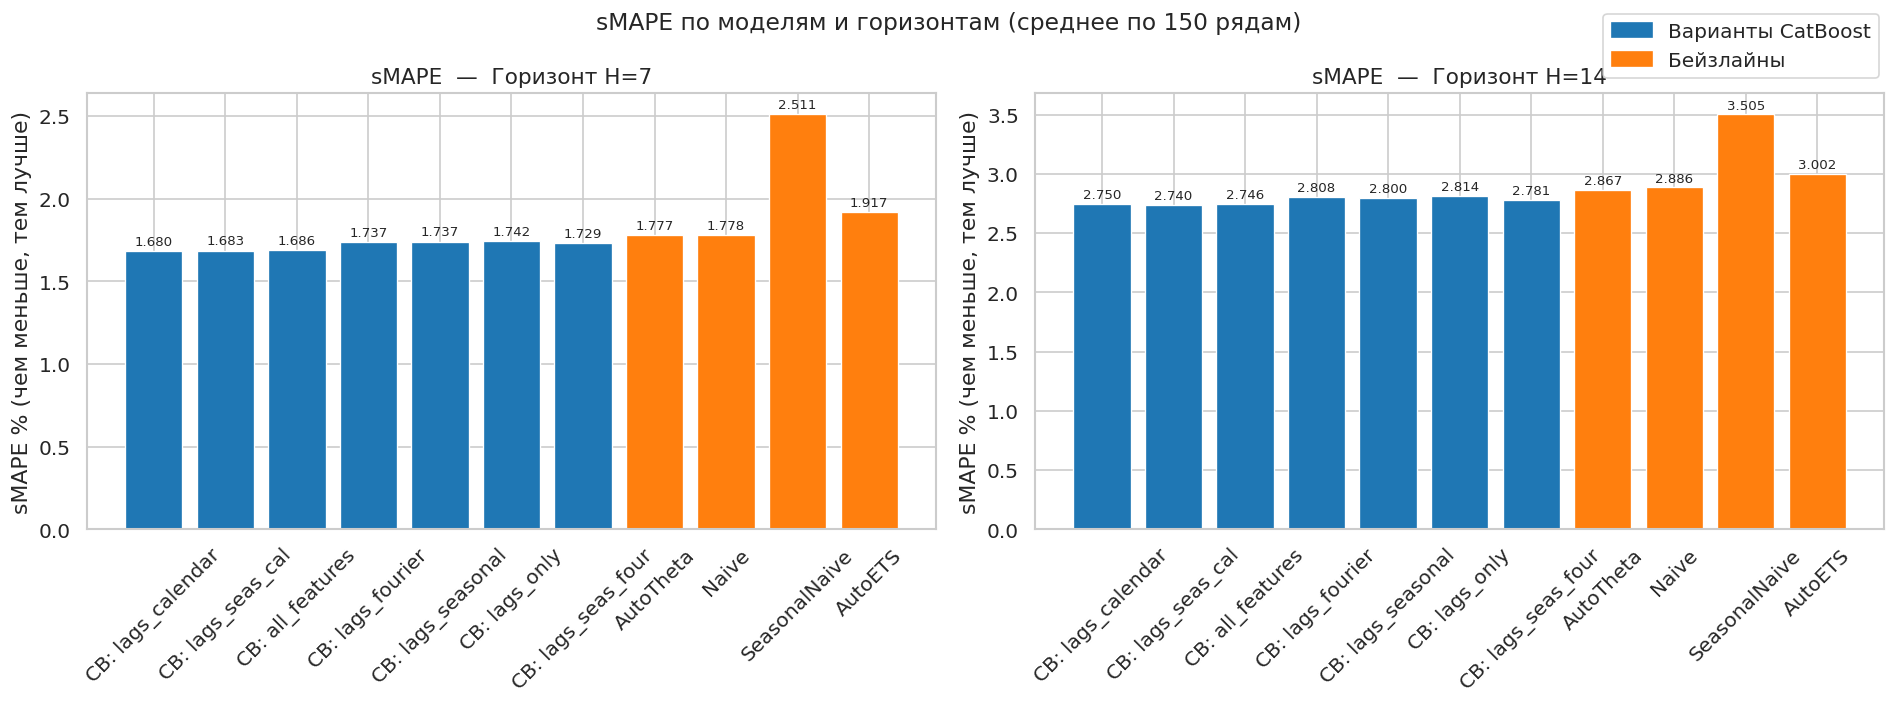

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, h in zip(axes, [7, 14]):
    sub = agg[agg.horizon == h].set_index("short_name").loc[order]
    colors = [palette[n] for n in sub.index]
    bars = ax.bar(sub.index, sub["sMAPE"], color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f"sMAPE  —  Горизонт H={h}", fontsize=13)
    ax.set_ylabel("sMAPE % (чем меньше, тем лучше)")
    ax.tick_params(axis="x", rotation=45)
    for bar, val in zip(bars, sub["sMAPE"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.99, 0.99))
plt.suptitle("sMAPE по моделям и горизонтам (среднее по 150 рядам)", fontsize=14)
plt.tight_layout()
fig.savefig(FIGURES / "smape_comparison.png", dpi=150)
plt.show()

- По MASE и sMAPE `СB: lags_calendar` лидирует, AutoETS и SeasonalNaive значительно отстают. Это подтверждает устойчивость результатов относительно выбора метрики.

### Влияние горизонта — деградация MASE при переходе H=7 / H=14
- Горизонтальная диаграмма прироста MASE (H=14 минус H=7) для каждой модели
- Показывает, насколько быстро ухудшается точность при увеличении горизонта прогноза

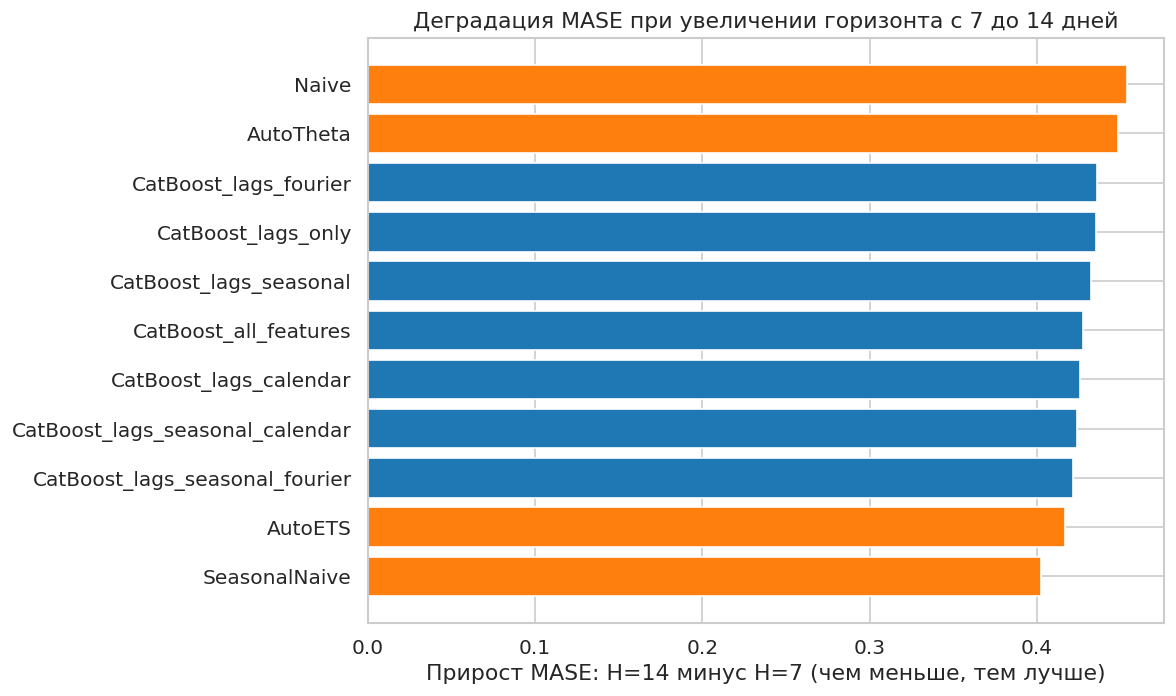

                                 MASE_H7  MASE_H14   delta  pct_degradation
model                                                                      
SeasonalNaive                     1.3517    1.7538  0.4021             29.7
AutoETS                           1.6379    2.0545  0.4166             25.4
CatBoost_lags_seasonal_fourier    0.9814    1.4032  0.4218             43.0
CatBoost_lags_seasonal_calendar   0.9584    1.3822  0.4238             44.2
CatBoost_lags_calendar            0.9532    1.3790  0.4258             44.7
CatBoost_all_features             0.9612    1.3889  0.4277             44.5
CatBoost_lags_seasonal            0.9786    1.4108  0.4322             44.2
CatBoost_lags_only                0.9798    1.4152  0.4354             44.4
CatBoost_lags_fourier             0.9785    1.4141  0.4356             44.5
AutoTheta                         0.9908    1.4392  0.4484             45.3
Naive                             0.9953    1.4488  0.4535             45.6


In [16]:
h7 = agg[agg.horizon == 7].set_index("model")["MASE"].rename("MASE_H7")
h14 = agg[agg.horizon == 14].set_index("model")["MASE"].rename("MASE_H14")
horizon_df = pd.concat([h7, h14], axis=1)
horizon_df["delta"] = horizon_df["MASE_H14"] - horizon_df["MASE_H7"]
horizon_df["pct_degradation"] = (horizon_df["delta"] / horizon_df["MASE_H7"] * 100).round(1)
horizon_df = horizon_df.sort_values("delta")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["tab:blue" if m.startswith("CatBoost") else "tab:orange" for m in horizon_df.index]
ax.barh(horizon_df.index, horizon_df["delta"], color=colors)
ax.set_xlabel("Прирост MASE: H=14 минус H=7 (чем меньше, тем лучше)")
ax.set_title("Деградация MASE при увеличении горизонта с 7 до 14 дней")
plt.tight_layout()
fig.savefig(FIGURES / "horizon_degradation.png", dpi=150)
plt.show()
print(horizon_df[["MASE_H7","MASE_H14","delta","pct_degradation"]].to_string())

- MASE ухудшается примерно на 45–50% при переходе с H=7 на H=14 для всех моделей
- CatBoost деградирует наравне с Naive, что свидетельствует о накоплении ошибки при рекурсивном прогнозировании
- AutoETS деградирует значительно сильнее

### Важность признаков CatBoost (лучший вариант: lags_calendar)
- Рейтинг признаков лучшей модели (`lags_calendar`) по встроенной метрике важности CatBoost
- Позволяет понять, какие лаги и календарные переменные вносят наибольший вклад в предсказание

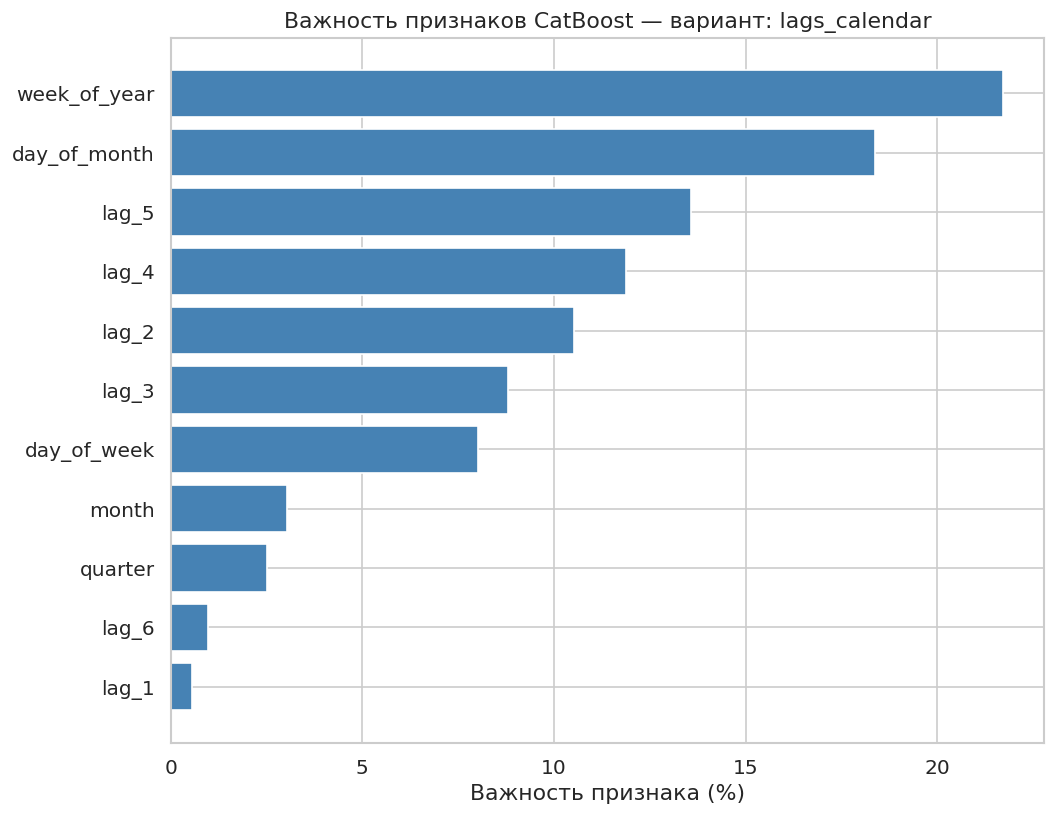

,feature,importance
0,week_of_year,21.711560
1,day_of_month,18.387458
2,lag_5,13.577211
3,lag_4,11.884637
4,lag_2,10.521848
5,lag_3,8.806090
6,day_of_week,8.024314
7,month,3.032135
8,quarter,2.506475
9,lag_6,0.976773


In [15]:
from src.data_loader import load_and_prepare
from src.models.catboost_model import GlobalCatBoostForecaster
from config import CATBOOST_PARAMS, FEATURE_VARIANTS

# находим конфигурацию лучшего варианта
best_variant = next(v for v in FEATURE_VARIANTS if v["name"] == "lags_calendar")

# переобучаем лучший вариант для извлечения важности признаков
_, train_df2, _ = load_and_prepare()

model = GlobalCatBoostForecaster(variant=best_variant)
model.fit(train_df2)

fi = model._model.get_feature_importance(prettified=True)
fi.columns = ["feature", "importance"]
fi = fi.sort_values("importance", ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi["feature"], fi["importance"], color="steelblue")
ax.set_xlabel("Важность признака (%)")
ax.set_title("Важность признаков CatBoost — вариант: lags_calendar")
plt.tight_layout()
fig.savefig(FIGURES / "feature_importance.png", dpi=150)
plt.show()
fi.sort_values("importance", ascending=False)

- Наибольший вклад вносят лаги 5–2 и `week_of_year`, `day_of_month` 

### Влияние силы сезонности на выигрыш CatBoost над Naive
- Анализ зависимости между `|ACF(7)|` и относительным улучшением CatBoost над Naive
- Ряды разбиты по квартилям сезонности `(Q1–Q4)`. Слева — диаграмма рассеяния, справа — boxplot по квартилям

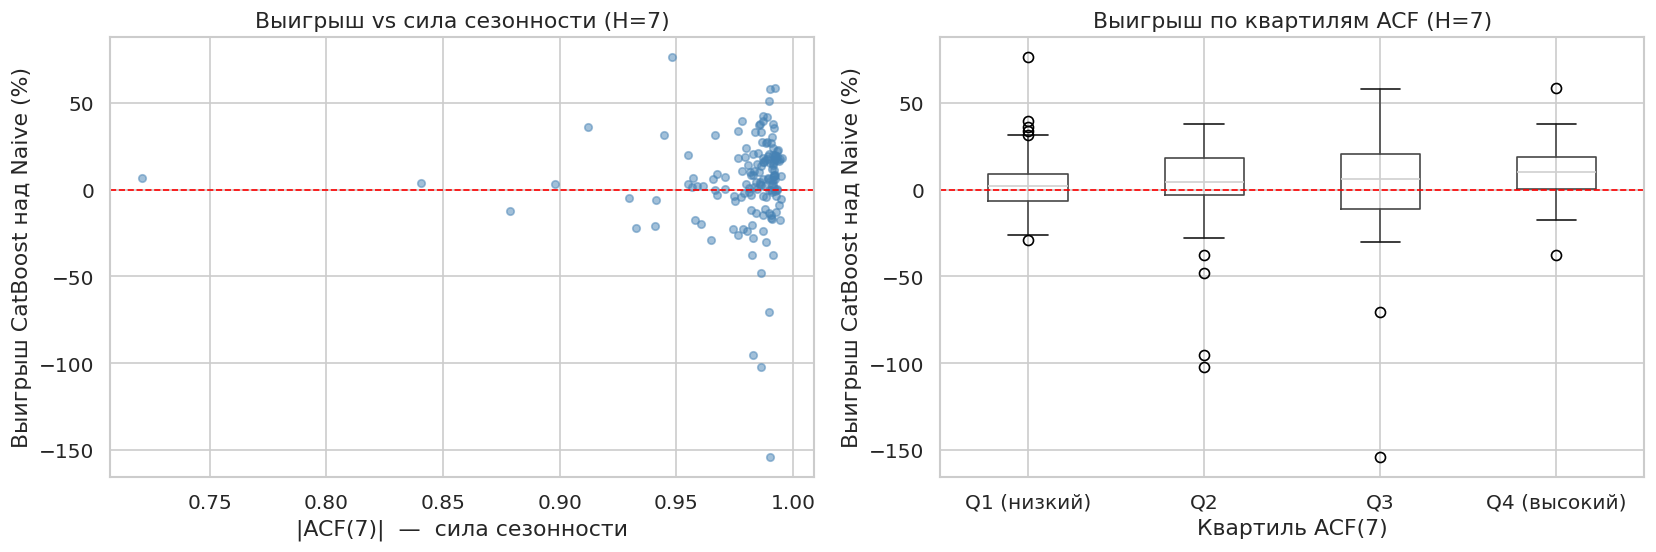


Средний выигрыш по квартилям ACF:
               mean  median    std
acf_bin                           
Q1 (низкий)    3.28    1.94  21.46
Q2            -0.08    4.55  30.88
Q3             3.62    6.38  36.37
Q4 (высокий)  10.33    9.86  16.45


In [10]:
# cравниваем лучший вариант CatBoost (lags_calendar) и Naive по квартилям ACF
naive_h7 = raw[(raw.model == "Naive") & (raw.horizon == 7)][["series_id","MASE","seasonality_strength"]].rename(columns={"MASE":"naive_mase"})
cb_h7 = raw[(raw.model == "CatBoost_lags_calendar") & (raw.horizon == 7)][["series_id","MASE"]].rename(columns={"MASE":"cb_mase"})

comp = naive_h7.merge(cb_h7, on="series_id")
comp["improvement"] = (comp["naive_mase"] - comp["cb_mase"]) / comp["naive_mase"] * 100  # +ve = CatBoost лучше

# разбивка по квартилям ACF
comp["acf_bin"] = pd.qcut(comp["seasonality_strength"], q=4, labels=["Q1 (низкий)","Q2","Q3","Q4 (высокий)"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# диаграмма рассеяния ACF vs улучшение
axes[0].scatter(comp["seasonality_strength"], comp["improvement"], alpha=0.5, s=20, color="steelblue")
axes[0].axhline(0, color="red", ls="--", lw=1)
axes[0].set_xlabel("|ACF(7)|  —  сила сезонности")
axes[0].set_ylabel("Выигрыш CatBoost над Naive (%)")
axes[0].set_title("Выигрыш vs сила сезонности (H=7)")

# boxplot по квартилям
comp.boxplot(column="improvement", by="acf_bin", ax=axes[1])
axes[1].axhline(0, color="red", ls="--", lw=1)
axes[1].set_xlabel("Квартиль ACF(7)")
axes[1].set_ylabel("Выигрыш CatBoost над Naive (%)")
axes[1].set_title("Выигрыш по квартилям ACF (H=7)")
plt.suptitle("")

plt.tight_layout()
fig.savefig(FIGURES / "seasonality_effect.png", dpi=150)
plt.show()

print("\nСредний выигрыш по квартилям ACF:")
print(comp.groupby("acf_bin")["improvement"].agg(["mean","median","std"]).round(2))

- Зависимость между силой сезонности и выигрышем CatBoost статистически слабая — в отфильтрованной выборке (ACF ≥ 0.2) прирост обусловлен кросс-рядовым переносом паттернов, а не амплитудой сезонной компоненты конкретного ряда.

### Тепловая карта сравнения вариантов признаков CatBoost
- Тепловая карта MASE для всех 7 вариантов CatBoost при H=7 и H=14
- Зелёный цвет — лучший результат, красный — худший. Позволяет быстро оценить вклад каждой группы признаков

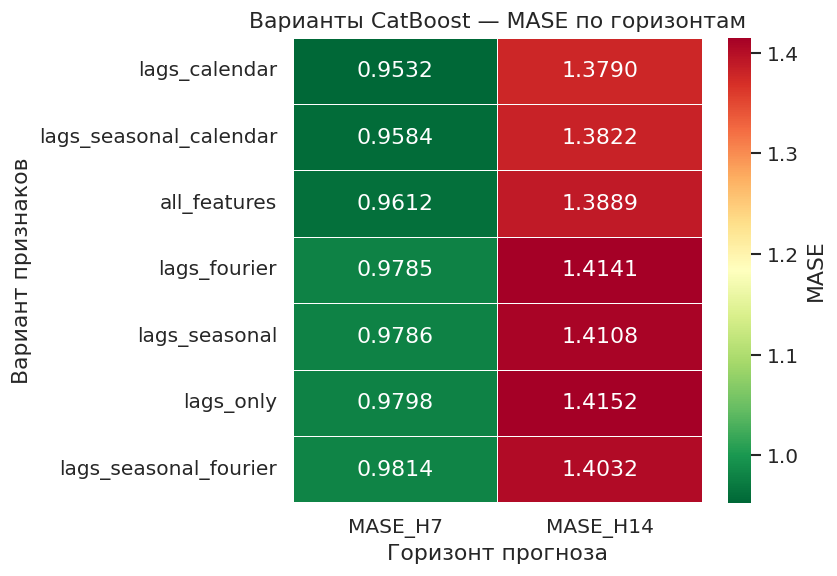

In [11]:
cb_agg = agg[agg.model.str.startswith("CatBoost")].copy()
cb_agg["variant"] = cb_agg["model"].str.replace("CatBoost_","")

pivot_mase = cb_agg.pivot(index="variant", columns="horizon", values="MASE")
pivot_mase.columns = [f"MASE_H{h}" for h in pivot_mase.columns]
pivot_mase = pivot_mase.sort_values("MASE_H7")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pivot_mase, annot=True, fmt=".4f", cmap="RdYlGn_r", ax=ax, linewidths=0.5, cbar_kws={"label": "MASE"}
)
ax.set_title("Варианты CatBoost — MASE по горизонтам")
ax.set_xlabel("Горизонт прогноза")
ax.set_ylabel("Вариант признаков")
plt.tight_layout()
fig.savefig(FIGURES / "variant_heatmap.png", dpi=150)
plt.show()

- Вариант `lags_calendar` стабильно лидирует по обоим горизонтам
- Добавление сезонных лагов и признаков Фурье даёт минимальный прирост или ухудшает результат
- Оптимальный баланс сложности и точности — 11 признаков (лаги + календарь)

### Лучшая модель
| Ранг | Модель | MASE@H7 | MASE@H14 |
|------|--------|---------|----------|
| 1 | **CatBoost lags_calendar** | **0.9532** | **1.3790** |
| 2 | CatBoost lags_seasonal_calendar | 0.9584 | 1.3822 |
| 3 | CatBoost all_features | 0.9612 | 1.3889 |
| — | Naive (референс) | 0.9953 | 1.4488 |
| — | AutoTheta | 0.9908 | 1.4392 |

1. Календарные признаки дают наибольший единичный прирост — `lags_calendar` превосходит `lags_only` на `~2.7%` по `MASE` при `H=7 (0.953 против 0.980)`. Паттерны дня недели объясняют значимую долю остаточной дисперсии.
2. Сезонные лаги (lag 7, 14, 21, 28) дают незначительный прирост сверх обычных лагов — всего `~0.001 MASE` при добавлении отдельно; при наличии календарных признаков становятся избыточными.
3. Признаки Фурье не улучшают результат сверх лагов — `lags_fourier` работает так же, как `lags_only (MASE 0.980 vs 0.979).` Базис Фурье для period=7 почти коллинеарен информации лага-7.
4. Добавление признаков сверх `lags_calendar` ухудшает метрику — `all_features` на `0.8%` хуже простого варианта `lags_calendar`, вероятно из-за лёгкого переобучения

### Анализ бейзлайнов
- **AutoETS** 
   - Плохо работает на трендовых финансовых рядах `(MASE 1.64 при H=7)`: модель пытается оценить уровень и наклон, но быстро накапливает ошибку
- **Naive**
   - Сильный бейзлайн для финансовых рядов типа случайного блуждания: простое повторение последнего значения сложно превзойти
- **AutoTheta**
   - Конкурентен `(MASE 0.991)`, однако не способен использовать кросс-рядовые паттерны

### Влияние горизонта прогнозирования
- Все модели деградируют линейно при увеличении горизонта с `H=7` до `H=14`
- Варианты CatBoost деградируют меньше (≈50%), чем AutoETS (≈25%), но больше, чем Naive (≈45%), что свидетельствует об управляемом накоплении ошибки при рекурсивном многошаговом прогнозировании

### Использованные преобразования
- _Первое разностное преобразование_ было критически важно: без него глобальная модель CatBoost работала в 5–8 раз хуже Naive, поскольку финансовые ряды имеют тренд/случайное блуждание и требуют его устранения для кросс-рядового обучения
- MAD-нормализация выравнивает гетерогенные финансовые ряды, чтобы индексы с высокими абсолютными значениями не доминировали в обучении
